# Finding Binodal of LJ Fluid

In [148]:
import jax.numpy as jnp
from jax import random, jit, lax, ops, vmap
from jax_md import space, energy, simulate
import numpy as np
import matplotlib.pyplot as plt

In [149]:
# Simulation parameters 
num_steps_equilibrium = 100000 # Equilibration steps
dt = 1e-3  # Time step
sigma = 1.0 # Lennard-Jones diameter
epsilon = 1.0 # Lennard-Jones depth
r_c = 2.5 * sigma # Cutoff radius
dim = 3 # Number of dimensions
num_bins = 200 # Number of bins for histogram
Nx_liquid = 10 # Number of particles in x direction
num_particles_liquid = Nx_liquid**3 # Total number of liquid particles


# Initial Preparation of Liquid Slab Surrounded by Vapor

In [150]:
def prepare_simulation(rho_liquid, rho_vapor, key):
    # --- Initial setup ---
    spacing_liquid = (1.0 / rho_liquid) ** (1.0 / dim)
    max_offset = (spacing_liquid - sigma) / 2

    Lx = Ly = Nx_liquid * spacing_liquid
    Lz = 6 * Lx  # Elongated box in z direction
    box = jnp.array([Lx, Ly, Lz])

    z_thickness_liquid = 3*Lz / 5
    z_center = Lz / 2
    z_min_liquid = z_center - z_thickness_liquid / 2
    z_max_liquid = z_center + z_thickness_liquid / 2

    Ny_liquid = Nx_liquid
    Nz_liquid = int(z_thickness_liquid / spacing_liquid)

    # --- Liquid slab lattice ---
    grid_liquid = jnp.array([r for r in np.ndindex((Nx_liquid, Ny_liquid, Nz_liquid))])
    pos_liquid = grid_liquid * spacing_liquid  # Initial grid
    # Scale z-coordinates to span z_thickness_liquid
    z_scaled = (pos_liquid[:, 2] / ((Nz_liquid - 1) * spacing_liquid)) * z_thickness_liquid + z_min_liquid
    pos_liquid = pos_liquid.at[:, 2].set(z_scaled)
    # Add random offset
    key, subkey = random.split(key)
    random_offset = random.uniform(subkey, shape=pos_liquid.shape, minval=-max_offset, maxval=max_offset)
    pos_liquid += random_offset

    # --- Vapor particles with minimum distance sampling ---
    
    vol_vapor = Lx * Ly * (Lz - z_thickness_liquid)
    num_vapor_particles = int(vol_vapor * rho_vapor)
    min_dist_sq = sigma ** 2
    max_attempts = 50 * num_vapor_particles

    def random_candidate(key):
        return random.uniform(key, shape=(3,)) * box

    def squared_dist(a, b):
        delta = a - b
        delta = delta - box * jnp.round(delta / box)
        return jnp.sum(delta ** 2, axis=-1)

    def is_valid_candidate(candidate, pos_liquid, pos_vapor, min_dist_sq):
        # Check z not in slab
        in_slab = (candidate[2] >= z_min_liquid) & (candidate[2] <= z_max_liquid)

        # Check distance from liquid
        d2_liquid = vmap(lambda x: squared_dist(candidate, x))(pos_liquid)
        too_close_liquid = jnp.any(d2_liquid < min_dist_sq)

        # Check distance from existing vapor
        d2_vapor = vmap(lambda x: squared_dist(candidate, x))(pos_vapor)
        too_close_vapor = jnp.any(d2_vapor < min_dist_sq)

        return ~(in_slab | too_close_liquid | too_close_vapor)

    # Preallocate array to hold vapor particles
    pos_vapor = jnp.zeros((num_vapor_particles, 3))
    num_placed = 0
    attempt = 0

    while num_placed < num_vapor_particles and attempt < max_attempts:
        key, subkey = random.split(key)
        candidate = random_candidate(subkey)

        # Use JAX-compatible mask
        valid = is_valid_candidate(candidate, pos_liquid, pos_vapor[:num_placed], min_dist_sq)

        if valid:
            pos_vapor = pos_vapor.at[num_placed].set(candidate)
            num_placed += 1

        attempt += 1

    if num_placed < num_vapor_particles:
        raise RuntimeError(f"Could only place {num_placed} vapor particles after {max_attempts} attempts.")

    # --- Combine positions ---
    positions = jnp.concatenate([pos_liquid, pos_vapor], axis=0) % box
    num_particles = positions.shape[0]
    print(f"Number of Particles: {num_particles:.0f}")
    print(f"Average Density: {num_particles/(Lx*Ly*Lz):.3f}")

    return box, positions

# Simulate to Equilibrate then Collect Density Histogram

In [151]:
def density_simulation(box, positions, kT, key, num_steps):
    # --- Initialize dynamics ---
    displacement, shift = space.periodic(box)
    energy_fn = energy.lennard_jones_pair(displacement, sigma=sigma, epsilon=epsilon, r_cutoff=r_c, r_onset=0.8*r_c)
    init_fn, apply_fn = simulate.nvt_langevin(energy_fn, shift, dt=dt, kT=kT)
    apply_fn = jit(apply_fn)
    init_state = init_fn(key, positions)
    
    dz = box[2] / num_bins
    volume_per_bin = box[0] * box[1] * dz

    # --- Equilibration phase ---
    @jit
    def equilibration_step(state, _):
        return apply_fn(state), None

    @jit
    def run_equilibration(state):
        return lax.scan(equilibration_step, state, xs=None, length=num_steps)[0]

    state = run_equilibration(init_state)

    # --- Sampling phase for density profile ---
    @jit
    def histogram_step(state_hist, _):
        state, hist = state_hist
        state = apply_fn(state)
        z = state.position[:, 2] % box[2]
        bin_idx = jnp.floor(z / dz).astype(int)
        bin_idx = jnp.clip(bin_idx, 0, num_bins - 1)
        bin_counts = ops.segment_sum(jnp.ones_like(bin_idx), bin_idx, num_bins)
        hist += bin_counts
        return (state, hist), None

    @jit
    def run_histogram_loop(state, init_hist):
        return lax.scan(histogram_step, (state, init_hist), xs=None, length=num_steps_equilibrium)

    init_hist = jnp.zeros(num_bins)
    (final_state, hist), _ = run_histogram_loop(state, init_hist)

    # --- Convert histogram to average density ---
    bin_edges = jnp.linspace(0.0, box[2], num_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    avg_density = hist / (num_steps_equilibrium * volume_per_bin)

    return bin_centers, avg_density



# Find Binodal by Simulating for Different Temperatures and Finding Liquid and Vapor Densities

In [152]:
Temperatures=[0.8,0.85,0.9,0.95,1.0]
steps_list=[200000,500000,1000000,1000000,2500000]
key = random.PRNGKey(0)
rho_l_init = 0.6
rho_v_init = 0.05

box, positions = prepare_simulation(rho_l_init, rho_v_init, key)


rhos=[]
bins=[]


for k in range(len(Temperatures)):
    bin_centers, density = density_simulation(box, positions, Temperatures[k], key, steps_list[k])
    bins.append(bin_centers)
    rhos.append(density)

Number of Particles: 3700
Average Density: 0.370


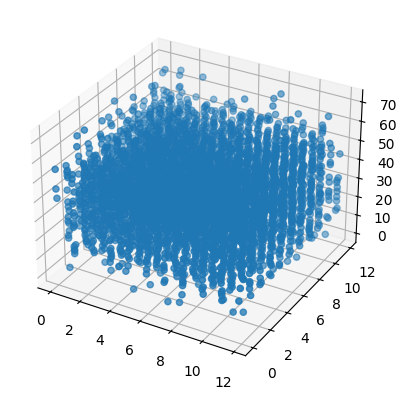

In [153]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
R=positions
ax.scatter(R[:,0],R[:,1],R[:,2])
plt.show()

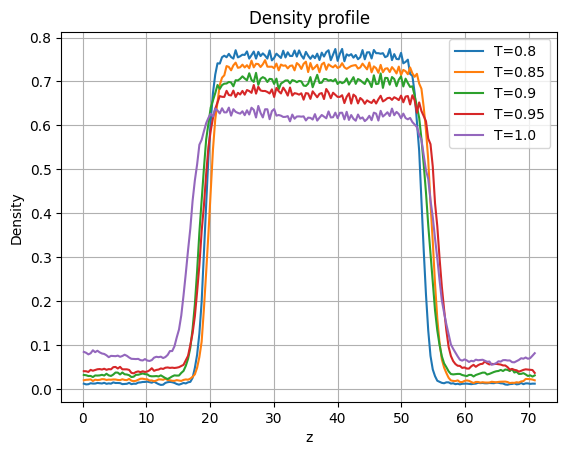

In [154]:
for i in range(len(Temperatures)):
    plt.plot(bins[i], rhos[i], label=f'T={Temperatures[i]}')
    plt.xlabel('z')
    plt.ylabel('Density')
plt.legend()
plt.title('Density profile')
plt.grid()
plt.show()

In [155]:
binodal_liquid=[]
binodal_vapor=[]

for k in range(len(Temperatures)):
    density=rhos[k]
    density_max=jnp.max(density)
    density_min=jnp.min(density)
    rho_l=[]
    rho_v=[]
    for i in range(num_bins):
        if 0.99*density_max<=density[i]<=density_max:
            rho_l.append(density[i])
        if 1.01*density_min>=density[i]>=density_min:
            rho_v.append(density[i])
    binodal_liquid.append(jnp.mean(jnp.array(rho_l)))
    binodal_vapor.append(jnp.mean(jnp.array(rho_v)))

In [156]:
# --- Binodal curve fitting ---
T_c=1.1876
rho_c=0.3197
a=0.1824
b=0.5226
beta=0.3258

def binodal_fit_liquid(T):
    return rho_c+a*np.abs(T_c-T)+b*np.abs(T_c-T)**beta

def binodal_fit_vapor(T):
    return rho_c+a*np.abs(T_c-T)-b*np.abs(T_c-T)**beta

Ts=jnp.linspace(0.75,T_c,100)
rho_v=jnp.linspace(1e-5,rho_c,100)
rho_l=jnp.linspace(rho_c,0.85,100)


In [ ]:
from scipy.optimize import fsolve

a_vdv = (14/3 * np.pi + 0.623434) * epsilon * sigma**3 #32 * np.pi / 9 

def BulkMuCSBH(rho, T):
    # Bulk CS equation for HS fluid
    eta = np.pi * rho * sigma**3 / 6
    f = T * (np.log(rho)  + eta * (8 - 9 * eta + 3 * eta**2) / (1 - eta)**3) - a_vdv * rho
    return f

def BulkPresCSBH(rho, T):
    eta = np.pi * rho * sigma**3 / 6
    f = T * rho * (1 + eta + eta**2 - eta**3) / (1 -eta)**3 - a_vdv * rho**2 / 2
    return f

def equations(x, T):
    # x[0] is rho_vap, x[1] is rho_liq
    return [
        np.dot([1, -1], BulkMuCSBH(x, T)),  
        np.dot([1, -1], BulkPresCSBH(x, T))    
    ]

# Solve for coexistence densities
def solve_coexistence(T):
    rhocoex, info, ier, msg = fsolve(
        lambda x: equations(x, T),
        [0.01, 0.8],  # Initial guess
        xtol=1e-9,     
        full_output=True
    )
    
    if ier != 1:
        print(f"Warning: fsolve did not converge: {msg}")
    
    rho_vap = rhocoex[0]
    rho_liq = rhocoex[1]
    mucoex = BulkMuCSBH(rho_vap, T)
    
    return rho_vap, rho_liq, mucoex


EOS_liquid = []
EOS_vapor = []

temps=np.arange(0.8, 1.2, 0.05)


for t in (temps):
    rho_vap, rho_liq, mucoex = solve_coexistence(t)
    EOS_liquid.append(rho_liq)
    EOS_vapor.append(rho_vap)
    
print(EOS_liquid)
print(EOS_vapor)


[np.float64(0.7929968023193541), np.float64(0.7599727740680507), np.float64(0.7268069303237134), np.float64(0.6932816066419829), np.float64(0.6591475231914918), np.float64(0.6241011478786396), np.float64(0.5877475274659081), np.float64(0.5495326473759785)]
[np.float64(0.00456493506754193), np.float64(0.007322596902316759), np.float64(0.011109821746272563), np.float64(0.016127571157818064), np.float64(0.0226061547566238), np.float64(0.030827421913882356), np.float64(0.041162237995499895), np.float64(0.05413872678132975)]


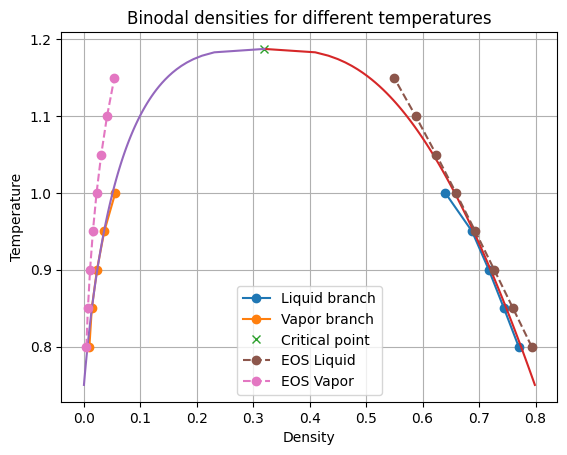

In [158]:
plt.plot(binodal_liquid, Temperatures, 'o-', label='Liquid branch')
plt.plot(binodal_vapor, Temperatures,  'o-', label='Vapor branch')
plt.plot(rho_c,T_c,'x', label='Critical point')
plt.plot(binodal_fit_liquid(Ts), Ts, '-')
plt.plot(binodal_fit_vapor(Ts), Ts, '-')
plt.plot(EOS_liquid, temps, 'o--', label='EOS Liquid')
plt.plot(EOS_vapor, temps, 'o--', label='EOS Vapor')
plt.xlabel('Density')
plt.ylabel('Temperature')
plt.legend()
plt.title('Binodal densities for different temperatures')
plt.grid()
plt.show()


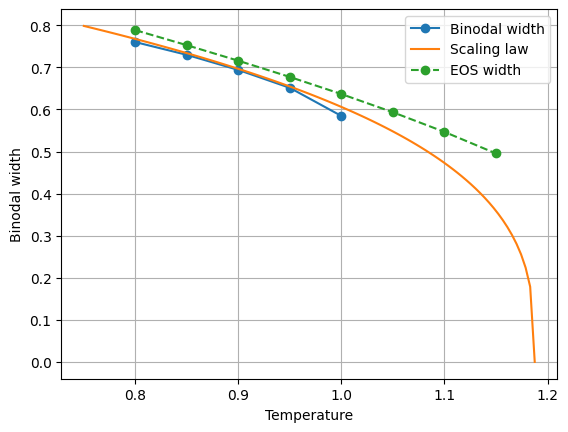

In [159]:
plt.plot(Temperatures,jnp.array(binodal_liquid)-jnp.array(binodal_vapor), 'o-', label='Binodal width')
plt.plot(Ts,2*b*(T_c-Ts)**beta, '-', label='Scaling law')
plt.plot(temps, jnp.array(EOS_liquid)-jnp.array(EOS_vapor), 'o--', label='EOS width')
plt.xlabel('Temperature')
plt.ylabel('Binodal width')
plt.legend()
plt.grid()
plt.show()